In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import LinearOperator, eigsh
from torch.utils.data import DataLoader
from scripts.utils import create_synthetic_dataset, FlatMLP, train_model
print("--- Original Exp 1: Temporal Genesis of Alignment ---")

--- Original Exp 1: Temporal Genesis of Alignment ---


In [2]:
dataset = create_synthetic_dataset()
input_dim = dataset.tensors[0].shape[1]
criterion = torch.nn.CrossEntropyLoss()
model = FlatMLP(input_dim=input_dim, hidden_dim=512, num_classes=10)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)
full_dataloader = torch.utils.data.DataLoader(dataset, batch_size=len(dataset), shuffle=False)

In [3]:
import torch
from scripts.utils import create_synthetic_dataset, FlatMLP, train_model


print("Phase 1: The Burn-in (Equilibration)...")
print("Training the model to reach the bottom of the minimum (theta*).")

# 3. Train the model to eliminate macroscopic drift
# We want it to thoroughly settle into the minimum, so 200-300 epochs is safe.
trained_model = train_model(
    dataset=dataset, 
    input_dim=input_dim,
    lr=0.005, 
    batch_size=64, 
    epochs=250
)

# 4. Freeze the state
# We will use this trained_model for Phase 2 and 3
trained_model.eval()
print("Equilibration complete! The model is now resting at theta*.")

Phase 1: The Burn-in (Equilibration)...
Training the model to reach the bottom of the minimum (theta*).
Epoch [100/250] | Loss: 0.0001 | Temp (lr/B): 0.00008
Epoch [200/250] | Loss: 0.0000 | Temp (lr/B): 0.00008
Equilibration complete! The model is now resting at theta*.



=== Running seed 1 ===
Phase 1: Training model to equilibrium...
Epoch [100/250] | Loss: 0.0001 | Temp (lr/B): 0.00008
Epoch [200/250] | Loss: 0.0000 | Temp (lr/B): 0.00008
Equilibration complete!
Phase 3: Computing noise eigenvectors (Sigma)...
Computing Hessian eigenvectors...
Seed 1 done. Overlap matrix computed.

=== Running seed 2 ===
Phase 1: Training model to equilibrium...
Epoch [100/250] | Loss: 0.0001 | Temp (lr/B): 0.00008
Epoch [200/250] | Loss: 0.0000 | Temp (lr/B): 0.00008
Equilibration complete!
Phase 3: Computing noise eigenvectors (Sigma)...
Computing Hessian eigenvectors...
Seed 2 done. Overlap matrix computed.

=== Running seed 3 ===
Phase 1: Training model to equilibrium...
Epoch [100/250] | Loss: 0.0001 | Temp (lr/B): 0.00008
Epoch [200/250] | Loss: 0.0000 | Temp (lr/B): 0.00008
Equilibration complete!
Phase 3: Computing noise eigenvectors (Sigma)...
Computing Hessian eigenvectors...
Seed 3 done. Overlap matrix computed.

=== Running seed 4 ===
Phase 1: Training m

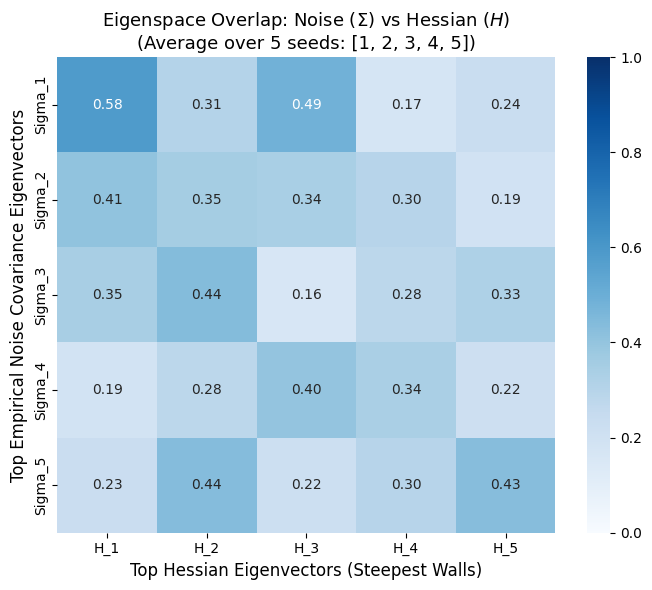

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse.linalg import LinearOperator, eigsh
from torch.utils.data import DataLoader
from scripts.utils import create_synthetic_dataset, FlatMLP, train_model

# --- Settings ---
SEEDS = [1, 2, 3, 4, 5]
K = 5           # Number of top dimensions to compare
B = 64          # Mini-batch size for the noise
num_noise_samples = 500

dataset = create_synthetic_dataset()
input_dim = dataset.tensors[0].shape[1]  # Should be 100

all_overlap_matrices = []

for SEED in SEEDS:
    print(f"\n=== Running seed {SEED} ===")
    torch.manual_seed(SEED)

    print("Phase 1: Training model to equilibrium...")
    trained_model = train_model(
        dataset=dataset,
        input_dim=input_dim,
        lr=0.005,
        batch_size=64,
        epochs=250,
        seed=SEED,
    )
    trained_model.eval()
    print("Equilibration complete!")

    criterion = torch.nn.CrossEntropyLoss()
    device = next(trained_model.parameters()).device
    full_dataloader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)

    # --- Function to get flattened gradient ---
    def get_flat_gradient(X_batch, y_batch):
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        trained_model.zero_grad()
        loss = criterion(trained_model(X_batch), y_batch)
        loss.backward()
        grads = [p.grad.contiguous().view(-1) for p in trained_model.parameters() if p.grad is not None]
        return torch.cat(grads)

    print("Phase 3: Computing noise eigenvectors (Sigma)...")
    X_full, y_full = next(iter(full_dataloader))
    true_grad = get_flat_gradient(X_full, y_full).detach().cpu().numpy()

    noise_gen = torch.Generator()
    noise_gen.manual_seed(SEED)
    mini_loader = DataLoader(dataset, batch_size=B, shuffle=True, generator=noise_gen)
    loader_iter = iter(mini_loader)

    noise_matrix = []
    for _ in range(num_noise_samples):
        try:
            X, y = next(loader_iter)
        except StopIteration:
            noise_gen.manual_seed(SEED)
            loader_iter = iter(DataLoader(dataset, batch_size=B, shuffle=True, generator=noise_gen))
            X, y = next(loader_iter)

        if len(X) != B:
            continue

        mini_grad = get_flat_gradient(X, y).detach().cpu().numpy()
        noise_vector = mini_grad - true_grad
        noise_matrix.append(noise_vector)

    noise_matrix = np.array(noise_matrix)
    noise_mean = noise_matrix.mean(axis=0, keepdims=True)
    centered_noise_matrix = noise_matrix - noise_mean

    U, S, Vh = np.linalg.svd(centered_noise_matrix, full_matrices=False)
    noise_eigenvectors = Vh[:K]

    print("Computing Hessian eigenvectors...")

    def compute_hvp(v_np):
        v_tensor = torch.tensor(v_np, dtype=torch.float32).to(device)
        hvp_accum = torch.zeros_like(v_tensor)
        for X_b, y_b in DataLoader(dataset, batch_size=500):
            X_b, y_b = X_b.to(device), y_b.to(device)
            trained_model.zero_grad()
            loss = criterion(trained_model(X_b), y_b)
            grads = torch.autograd.grad(loss, trained_model.parameters(), create_graph=True)
            flat_grad = torch.cat([g.contiguous().view(-1) for g in grads])
            grad_v = torch.dot(flat_grad, v_tensor)
            hvp_grads = torch.autograd.grad(grad_v, trained_model.parameters())
            flat_hvp = torch.cat([g.contiguous().view(-1) for g in hvp_grads])
            hvp_accum += flat_hvp * len(X_b)
        return (hvp_accum / len(dataset)).detach().cpu().numpy()

    M = sum(p.numel() for p in trained_model.parameters())
    H_op = LinearOperator((M, M), matvec=compute_hvp)
    evals, evecs = eigsh(H_op, k=K, which='LA')
    hessian_eigenvectors = evecs[:, ::-1].T  # Shape: (K, M)

    overlap_matrix = np.abs(np.dot(noise_eigenvectors, hessian_eigenvectors.T))
    all_overlap_matrices.append(overlap_matrix)
    print(f"Seed {SEED} done. Overlap matrix computed.")

# --- Average across seeds ---
avg_overlap_matrix = np.mean(all_overlap_matrices, axis=0)
print(f"\nAveraged overlap matrix over {len(SEEDS)} seeds.")

print("Plotting the averaged Alignment Heatmap...")
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(avg_overlap_matrix, annot=True, cmap='Blues', fmt=".2f",
            xticklabels=[f"H_{i+1}" for i in range(K)],
            yticklabels=[f"Sigma_{i+1}" for i in range(K)],
            vmin=0, vmax=1, ax=ax)

ax.set_title(
    f"Eigenspace Overlap: Noise ($\\Sigma$) vs Hessian ($H$)\n"
    f"(Average over {len(SEEDS)} seeds: {SEEDS})",
    fontsize=13
)
ax.set_xlabel("Top Hessian Eigenvectors (Steepest Walls)", fontsize=12)
ax.set_ylabel("Top Empirical Noise Covariance Eigenvectors", fontsize=12)

plt.tight_layout()
plt.savefig("Hessian_Noise_Alignment_avg.png", dpi=300)
plt.show()


Alignment evolution: Noise covariance Σ vs Hessian H eigenspace
  K = 5,  lr = 0.005,  B = 64,  total_steps = 30
  Seeds: [1, 2, 3, 4, 5]
  Alignment snapshots at steps: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]

  Seed 1
  Model dimension M = 56842
  Random-subspace baseline = 8.80e-05

  Step      0  loss = 2.8240  avg cos²θ = 0.16676  (3.2s)
  Step      1  loss = 1.5000  avg cos²θ = 0.36323  (2.9s)
  Step      2  loss = 0.7678  avg cos²θ = 0.47052  (4.7s)
  Step      3  loss = 0.4249  avg cos²θ = 0.78334  (4.2s)
  Step      4  loss = 0.2992  avg cos²θ = 0.75798  (2.9s)
  Step      5  loss = 0.2140  avg cos²θ = 0.87181  (3.2s)
  Step      6  loss = 0.1597  avg cos²θ = 0.90293  (3.2s)
  Step      7  loss = 0.1322  avg cos²θ = 0.90963  (1116.9s)
  Step      8  loss = 0.1130  avg cos²θ = 0.88389  (3875.1s)
  Step      9  loss = 0.0975  avg cos²θ = 0.88651  (5.8s)
  Step     10  loss = 0.0856  avg cos²θ = 0.86152  (4.4s

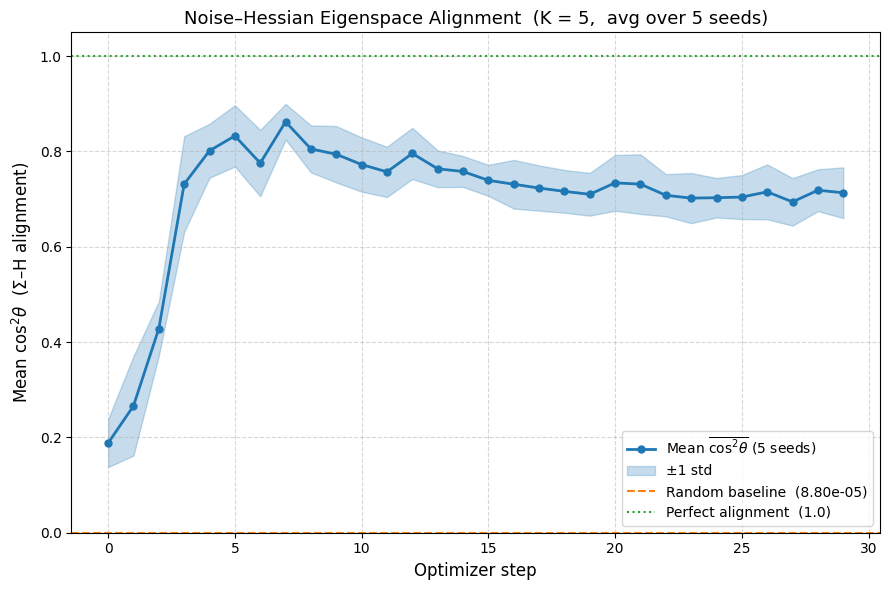

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.sparse.linalg import LinearOperator, eigsh
from torch.utils.data import DataLoader
from scripts.utils import FlatMLP

# ── Settings ───────────────────────────────────────────────────────────────────
K_align        = 5       # subspace dimension (same as heatmap)
B_noise        = 64      # batch size for noise sampling
num_noise      = 150     # noise samples per snapshot
lr_train       = 0.005
B_train        = 64
total_steps    = 30      # optimizer steps
steps_per_loss = 500     # full-batch loss evaluation interval
SEEDS          = [1, 2, 3, 4, 5]
NOISE_SEED     = 0       # fixed seed for mini-batch draws in every snapshot

# Alignment snapshots: dense early, coarser later
snapshot_steps = sorted(set(range(0, 30, 1)))
snapshot_set   = set(snapshot_steps)

print(f"Alignment evolution: Noise covariance Σ vs Hessian H eigenspace")
print(f"  K = {K_align},  lr = {lr_train},  B = {B_train},  total_steps = {total_steps}")
print(f"  Seeds: {SEEDS}")
print(f"  Alignment snapshots at steps: {snapshot_steps}")

# ── Helper: top-K noise covariance eigenvectors ────────────────────────────────
def get_noise_eigenvectors(model, dataset, B, num_samples, K, device, seed=0):
    crit = torch.nn.CrossEntropyLoss()
    X_f, y_f = dataset.tensors[0].to(device), dataset.tensors[1].to(device)
    model.zero_grad()
    crit(model(X_f), y_f).backward()
    true_g = torch.cat([p.grad.contiguous().view(-1) for p in model.parameters()
                        if p.grad is not None]).detach().cpu().numpy()

    g_noise = torch.Generator()
    g_noise.manual_seed(seed)
    loader = DataLoader(dataset, batch_size=B, shuffle=True, generator=g_noise)
    it = iter(loader)
    samples = []
    while len(samples) < num_samples:
        try:
            Xb, yb = next(it)
        except StopIteration:
            g_noise.manual_seed(seed)
            it = iter(DataLoader(dataset, batch_size=B, shuffle=True, generator=g_noise))
            Xb, yb = next(it)
        if len(Xb) != B:
            continue
        model.zero_grad()
        Xb, yb = Xb.to(device), yb.to(device)
        crit(model(Xb), yb).backward()
        mini_g = torch.cat([p.grad.contiguous().view(-1) for p in model.parameters()
                            if p.grad is not None]).detach().cpu().numpy()
        samples.append(mini_g - true_g)

    noise_mat = np.array(samples)
    noise_mat -= noise_mat.mean(axis=0, keepdims=True)
    _, _, Vh = np.linalg.svd(noise_mat, full_matrices=False)
    return Vh[:K]   # (K, M)

# ── Helper: top-K Hessian eigenvectors ────────────────────────────────────────
def get_hessian_eigenvectors(model, dataset, K, device):
    crit = torch.nn.CrossEntropyLoss()
    M_dim = sum(p.numel() for p in model.parameters())

    def hvp(v_np):
        v_t = torch.tensor(v_np, dtype=torch.float32, device=device)
        accum = torch.zeros_like(v_t)
        for Xb, yb in DataLoader(dataset, batch_size=512, shuffle=False):
            Xb, yb = Xb.to(device), yb.to(device)
            model.zero_grad()
            loss = crit(model(Xb), yb)
            grads = torch.autograd.grad(loss, model.parameters(), create_graph=True)
            gv = torch.dot(torch.cat([g.contiguous().view(-1) for g in grads]), v_t)
            hg = torch.autograd.grad(gv, model.parameters())
            accum += torch.cat([g.contiguous().view(-1) for g in hg]) * len(Xb)
        return (accum / len(dataset)).detach().cpu().numpy()

    H_op = LinearOperator((M_dim, M_dim), matvec=hvp)
    _, evecs_snap = eigsh(H_op, k=K, which='LA', tol=1e-3)
    return evecs_snap[:, ::-1].T   # (K, M)

# ── Helper: average cos²(θ) between two K-dim subspaces ───────────────────────
def mean_cos2_theta(Q_a, Q_b):
    G  = Q_a @ Q_b.T
    sv = np.linalg.svd(G, compute_uv=False)
    return float(np.mean(sv ** 2))

# ── Full-batch loss evaluation ─────────────────────────────────────────────────
def full_batch_loss(model, dataset, device, batch_size=512):
    crit = torch.nn.CrossEntropyLoss()
    total_loss, total_n = 0.0, 0
    model.eval()
    with torch.no_grad():
        for Xb, yb in DataLoader(dataset, batch_size=batch_size, shuffle=False):
            Xb, yb = Xb.to(device), yb.to(device)
            total_loss += crit(model(Xb), yb).item() * len(Xb)
            total_n    += len(Xb)
    model.train()
    return total_loss / total_n

# ── Run over all seeds ─────────────────────────────────────────────────────────
# all_histories[seed_idx] = list of (step, avg_cos2)
all_histories   = []
all_loss_hists  = []

M_dim          = None
random_baseline = None
t_start        = time.perf_counter()

for SEED in SEEDS:
    print(f"\n{'='*60}")
    print(f"  Seed {SEED}")
    print(f"{'='*60}")

    torch.manual_seed(SEED)
    track_model = FlatMLP(input_dim=input_dim, hidden_dim=512, num_classes=10)
    opt_track   = torch.optim.SGD(track_model.parameters(), lr=lr_train)
    crit_track  = torch.nn.CrossEntropyLoss()
    device_t    = next(track_model.parameters()).device

    if M_dim is None:
        M_dim           = sum(p.numel() for p in track_model.parameters())
        random_baseline = K_align / M_dim
        print(f"  Model dimension M = {M_dim}")
        print(f"  Random-subspace baseline = {random_baseline:.2e}\n")

    train_loader = DataLoader(dataset, batch_size=B_train, shuffle=True,
                              generator=torch.Generator().manual_seed(SEED))

    alignment_history = []   # (step, avg_cos2)
    loss_history      = []   # (step, loss)

    global_step = 0
    done        = False

    # Measure at step 0
    fl = full_batch_loss(track_model, dataset, device_t)
    loss_history.append((0, fl))
    track_model.eval()
    t0     = time.perf_counter()
    Q_noise = get_noise_eigenvectors(track_model, dataset, B_noise, num_noise,
                                     K_align, device_t, seed=NOISE_SEED)
    Q_hess  = get_hessian_eigenvectors(track_model, dataset, K_align, device_t)
    avg_c2  = mean_cos2_theta(Q_noise, Q_hess)
    alignment_history.append((0, avg_c2))
    print(f"  Step {0:6d}  loss = {fl:.4f}  avg cos²θ = {avg_c2:.5f}  ({time.perf_counter()-t0:.1f}s)")
    track_model.train()

    while not done:
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device_t), yb.to(device_t)
            opt_track.zero_grad()
            crit_track(track_model(Xb), yb).backward()
            opt_track.step()
            global_step += 1

            if global_step % steps_per_loss == 0:
                fl = full_batch_loss(track_model, dataset, device_t)
                loss_history.append((global_step, fl))

            if global_step in snapshot_set:
                fl_snap = full_batch_loss(track_model, dataset, device_t)
                if not loss_history or loss_history[-1][0] != global_step:
                    loss_history.append((global_step, fl_snap))
                track_model.eval()
                t0      = time.perf_counter()
                Q_noise = get_noise_eigenvectors(track_model, dataset, B_noise,
                                                 num_noise, K_align, device_t,
                                                 seed=NOISE_SEED)
                Q_hess  = get_hessian_eigenvectors(track_model, dataset, K_align, device_t)
                avg_c2  = mean_cos2_theta(Q_noise, Q_hess)
                alignment_history.append((global_step, avg_c2))
                print(f"  Step {global_step:6d}  loss = {fl_snap:.4f}  avg cos²θ = {avg_c2:.5f}"
                      f"  ({time.perf_counter()-t0:.1f}s)")
                track_model.train()

            if global_step >= total_steps:
                done = True
                break

    all_histories.append(alignment_history)
    all_loss_hists.append(loss_history)
    print(f"  Seed {SEED} done.")

print(f"\nTotal time: {time.perf_counter()-t_start:.1f}s")

# ── Aggregate across seeds ─────────────────────────────────────────────────────
# All seeds share the same snapshot_steps, so we can stack directly.
steps_arr = [s for s, _ in all_histories[0]]
cos2_matrix = np.array([[c for _, c in hist] for hist in all_histories])  # (n_seeds, n_steps)

mean_cos2 = cos2_matrix.mean(axis=0)
std_cos2  = cos2_matrix.std(axis=0)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax_align = plt.subplots(1, 1, figsize=(9, 6))

ax_align.plot(steps_arr, mean_cos2, marker='o', color='tab:blue', linewidth=2,
              markersize=5, label=r'Mean $\overline{\cos^2\!\theta}$ (5 seeds)')
ax_align.fill_between(steps_arr,
                      mean_cos2 - std_cos2,
                      mean_cos2 + std_cos2,
                      alpha=0.25, color='tab:blue', label=r'±1 std')
ax_align.axhline(random_baseline, color='tab:orange', linestyle='--', linewidth=1.5,
                 label=f'Random baseline  ({random_baseline:.2e})')
ax_align.axhline(1.0, color='tab:green', linestyle=':', linewidth=1.5,
                 label='Perfect alignment  (1.0)')
ax_align.set_xlabel('Optimizer step', fontsize=12)
ax_align.set_ylabel(r'Mean $\cos^2\!\theta$  (Σ–H alignment)', fontsize=12)
ax_align.set_title(
    f'Noise–Hessian Eigenspace Alignment  (K = {K_align},  avg over {len(SEEDS)} seeds)',
    fontsize=13
)
ax_align.set_ylim(bottom=0)
ax_align.legend(fontsize=10)
ax_align.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("Alignment_vs_Step_avg.png", dpi=300)
plt.show()
